# Limit to Recover Mangel and Clark

Checking that, in the appropriate limit, this model reduces to the classic Mangel and Clark (1986) model.

Here we look at the large-$P$ (total population size) limit: for a Gaussian fecundity function $W(x)$, we simulate the group-joining/leaving dynamics $dg_x/dt$ starting from almost everyone solitary (with a small seed of triads), and ask whether the equilibrium group-size distribution concentrates near the Mangel & Clark prediction $\hat{x}$ (the largest $x$ for which $W(x) \geq W(1)$) as $P$ grows.

## Setup

In [ ]:
using Revise
using CooperativeHuntingPkg
using DifferentialEquations
using Plots
using LaTeXStrings
using Measures

In [141]:
default(
    guidefontsize=16,   # controls xlabel, ylabel, title font size
    tickfontsize=12,    # controls axis number labels
    legendfontsize=16,  # controls legend font
    linewidth=3,        # controls default line thickness
    grid = false,        # turns off grid in background
    dpi=200,
    fontfamily="Computer Modern" # font family that matches latex
)

## Parameters

We use the Gaussian-fecundity version of the group dynamics, `fun_dg_simpleW!` (right-hand side of $dg_x/dt$) together with `fun_W_gauss` (per-capita fecundity $W(x) = a \exp(-(x-x_0)^2/(2\sigma^2))$).

- Optimal group size (that maximizes fecundity): $x_0 = 8$
- Maximum group size: $x_{max} = 20$

`leave_param` and `fuse_param` are left at 1 (unsuppressed leaving/fusing).

In [133]:
x0 = 4.0      # group size that maximizes fecundity
x_max = 20    # maximum group size

params_base = Dict{Symbol,Any}(
    :a           => 5.0,   # W height (max fecundity)
    :σ           => 2.0,   # standard deviation of W
    :x0          => x0,
    :Tg          => 0.1,   # group dynamics timescale
    :d           => 10,   # steepness of join/leave best-response function
    :x_max       => x_max,
    :leave_param => 1.0,   # ℓ: scales rate individuals leave groups
    :fuse_param  => 0.01    # φ: scales rate singletons fuse into groups
)

Dict{Symbol, Any} with 8 entries:
  :a           => 5.0
  :Tg          => 0.1
  :x0          => 4.0
  :σ           => 2.0
  :d           => 10
  :x_max       => 20
  :leave_param => 1.0
  :fuse_param  => 0.01

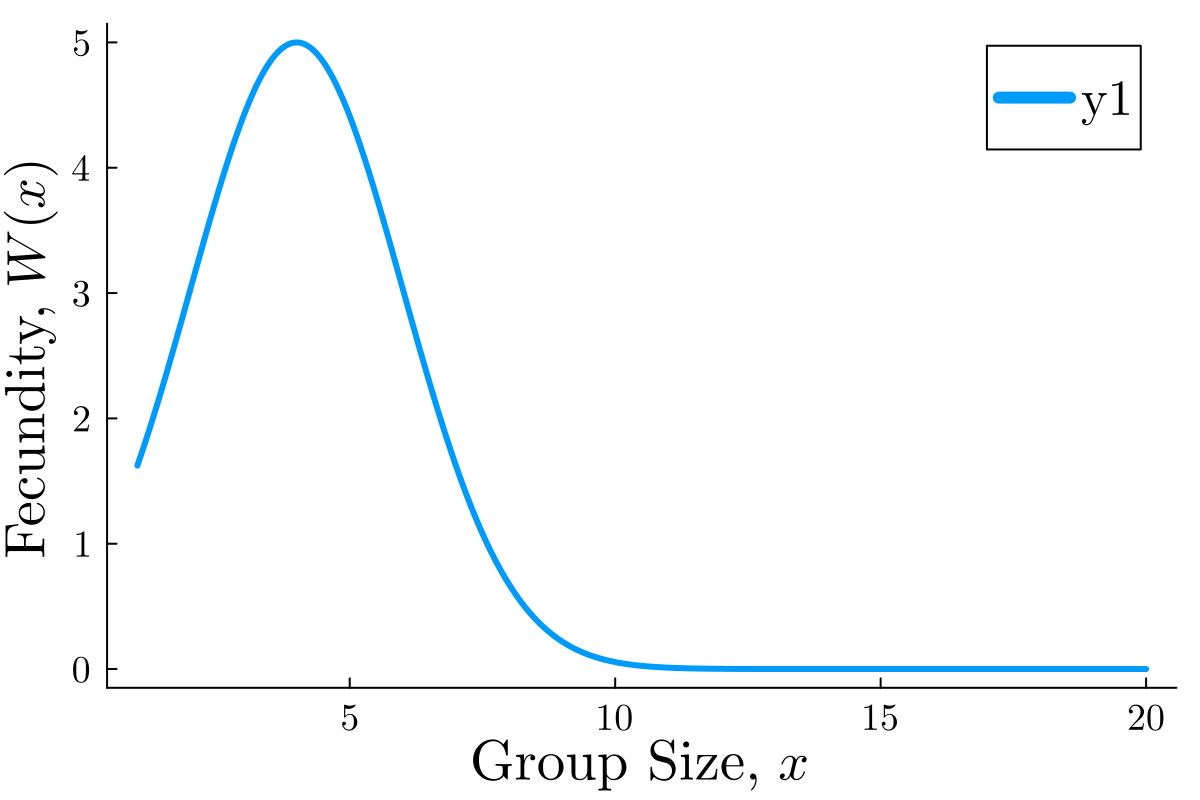

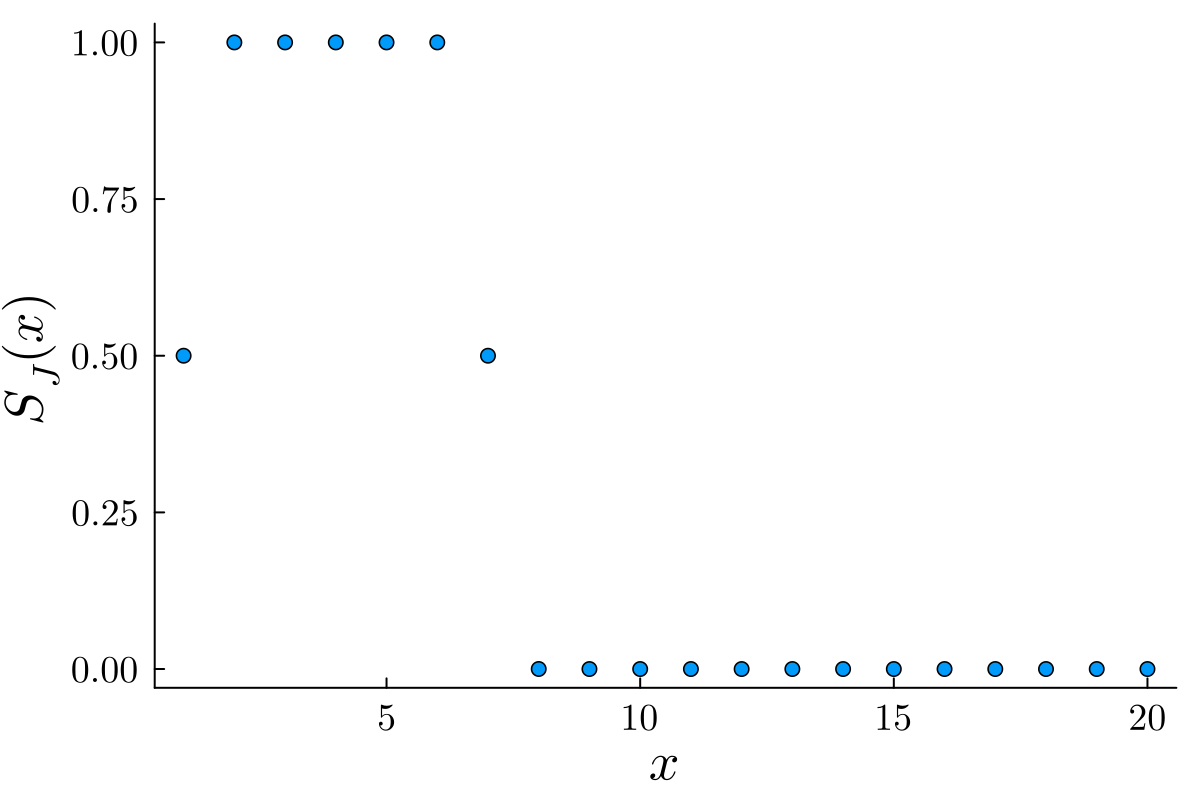

7
W(x_mc)=1.6232623367917487


In [134]:
W = fun_W_gauss(1:x_max, params_base)

xvec = 1:0.05:20
pW = plot(
    1:0.05:20, fun_W_gauss(xvec, params_base),
    xlabel = L"Group Size, $x$",
    ylabel = L"Fecundity, $W(x)$")
display(pW)
p = scatter(
    1:20, fun_S_given_W(W, W[1], params_base), 
    ylabel = L"S_J(x)", xlabel = L"x", legend = :none
    )
display(p)
x_mc = any(W[2:end] .< W[1]) ? findfirst(W[2:end] .< W[1]) : x_max
println(x_mc)
println("W(x_mc)=$(W[x_mc])")


## Take the limit: simulate across a range of $P$

For each total population size $P \in \{10^2, 10^3, 10^4, 10^5, 10^6\}$:

- Initial condition: $g_3 = 1$, $g_1 = P - 3 g_3$, all other $g_x = 0$.
- Integrate $dg_x/dt$ (via `fun_dg_simpleW!`) with `DifferentialEquations` out to $t_f = 10{,}000$ ("10,000 time steps").
- Compute the equilibrium probability of being in a group of size $x$, `prob_x = get_prob_in_x(g_final, P, x_max)`.

In [ ]:
t_f = 2.0
Pvec = [5.0,[10.0^n for n in 2:10]...]  # 10^2, 10^3, 10^4, 10^5, 10^6

prob_mat = zeros(length(Pvec), x_max)  # rows = P values, cols = group size x
x = 3
for (i, P) in enumerate(Pvec)
    println(P)
    g0 = zeros(x_max)
    
    g0[x] = 1.0
    g0[1] = P - x * g0[x]

    prob = ODEProblem(fun_dg_simpleW!, g0, (0.0, t_f), NamedTuple(params_base))
    sol = solve(prob)
    g_final = sol.u[end]

    prob_mat[i, :] = get_prob_in_x(g_final, P, x_max)
end

prob_mat

5.0
100.0
1000.0
10000.0
100000.0
1.0e6
1.0e7
1.0e8
1.0e9
1.0e10


10×20 Matrix{Float64}:
 2.12315e-6   0.00100513   0.0630171    …  2.27568e-117  -9.37605e-126
 0.02467      0.000250314  0.000381021     7.85736e-90    9.41383e-98
 0.00594047   5.9659e-5    8.988e-5        4.82781e-85    1.36715e-92
 0.00146025   1.46232e-5   2.1966e-5       3.26462e-80    2.2654e-87
 0.000339386  3.39578e-6   5.09644e-6      9.63004e-76    1.55169e-82
 7.63709e-5   7.63888e-7   1.1461e-6    …  1.76704e-71    6.40682e-78
 1.72242e-5   1.72261e-7   2.5842e-7       3.19594e-67    2.61459e-73
 4.17168e-6   4.17188e-8   6.25813e-8      1.33525e-62    2.64773e-68
 1.09344e-6   1.09346e-8   1.64022e-8      1.38276e-57    7.1725e-63
 1.71729e-7   1.71729e-9   2.57595e-9      2.88868e-55    2.33373e-60

## Plot prob_x vs P

Heatmap of the equilibrium probability of being in a group of size $x$ (color) against $P$ (x-axis, log scale) and group size $x$ (y-axis). The green line marks the Mangel & Clark prediction $\hat{x}$ (the largest $x$ with $W(x) \geq W(1)$), and the magenta line marks the fecundity-maximizing group size $x_0$.

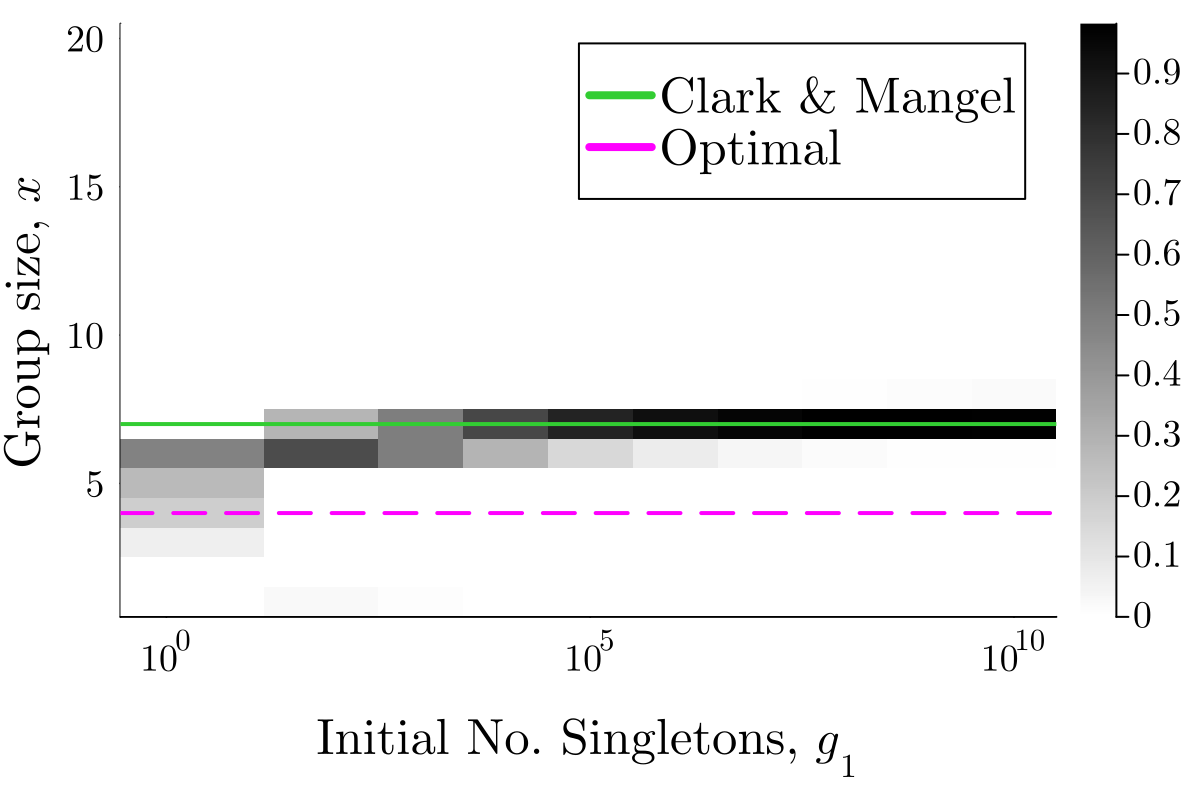

In [144]:
W = fun_W_gauss(1:x_max, params_base)
x_mc = any(W[2:end] .< W[1]) ? findfirst(W[2:end] .< W[1]) : x_max
x_opt = argmax(W)

hm = heatmap(
    Pvec .- x*g0[x],
    1:x_max,
    prob_mat',
    xscale = :log10,
    c = cgrad([:white, :black], 256),
    clims = (0.0, findmax(prob_mat)[1]),
    xlabel ="\n"* L"Initial No. Singletons, $g_1$",
    ylabel = L"Group size, $x$",
    bottom_margin=5mm
)
hline!(hm, [x_mc], label = "Clark & Mangel", color = :limegreen, linewidth = 2)
hline!(hm, [x_opt], label = "Optimal", color = :magenta, linewidth = 2, linestyle = :dash)

hm

## Combined figure: W(x) and S_J(x) stacked on the left, heatmap on the right

`pW` and `p` (both single-column-width plots) are stacked into one column with `grid(2,1)`, and placed next to `hm` (wider) using `@layout`. `size` and the `w`/`h` fractions below control the relative sizing — tweak `size` for overall figure dimensions and the `{0.55w}` fraction for how much horizontal space `hm` gets.

In [ ]:
fig_path = ""   # set to a folder path (ending in "/") if you want figures saved elsewhere

# (A) and (B) will be stacked in a narrower left column in LaTeX, so save them
# roughly square / portrait-ish; (C) will be wider, so give it more width.
savefig(pW, fig_path * "fecundity_W.pdf")
savefig(p,  fig_path * "best_response_SJ.pdf")
savefig(hm, fig_path * "prob_x_vs_P_heatmap.pdf")

LaTeX (using the `subcaption` package) to lay these out as (A) and (B) stacked on the left, (C) on the right, all inside one `figure` environment with shared numbering:

```latex
% preamble:
% \usepackage{graphicx}
% \usepackage{subcaption}

\begin{figure}[t]
    \centering
    \begin{minipage}[b]{0.38\textwidth}
        \centering
        \begin{subfigure}[b]{\textwidth}
            \centering
            \includegraphics[width=\textwidth]{fecundity_W.pdf}
            \caption{}
            \label{fig:W}
        \end{subfigure}
        \\[1em]
        \begin{subfigure}[b]{\textwidth}
            \centering
            \includegraphics[width=\textwidth]{best_response_SJ.pdf}
            \caption{}
            \label{fig:SJ}
        \end{subfigure}
    \end{minipage}
    \hfill
    \begin{subfigure}[b]{0.55\textwidth}
        \centering
        \includegraphics[width=\textwidth]{prob_x_vs_P_heatmap.pdf}
        \caption{}
        \label{fig:heatmap}
    \end{subfigure}
    \caption{(A) Fecundity $W(x)$. (B) Best-response function $S_J(x)$. (C) Equilibrium probability of experiencing group size $x$ as a function of population size $P$.}
    \label{fig:combined}
\end{figure}
```

`subcaption`'s `subfigure` environment auto-labels panels (A), (B), (C) (lowercase by default — add `\captionsetup[subfigure]{labelformat=parens}` or similar in the preamble to match the style used here, or just hardcode `\caption{(A)}`, etc. if you want to skip auto-labeling). The `minipage` groups (A) and (B) into a single column so `\hfill` treats that column and (C) as two side-by-side blocks; adjust the `0.38\textwidth` / `0.55\textwidth` widths to taste.

## Notes / Conclusions

If the model recovers Mangel & Clark in the large-$P$ limit, `prob_x` should become increasingly concentrated near $\hat{x}$ (green line) as $P$ grows from $10^2$ to $10^6$.